# **PPAR-Gamma Ligand-Pocket Graph Visualizer Notebook**

**Notebook 01:** Visualize graphs and hypergraphs representations for PPAR-gamma ligand target dataset.

1. **Ligand Hypergraphs** - Small molecules with pharmacophore features
2. **Protein Pocket Graphs** - Binding site residues that interact with ligands


- **Author:** Aaryesh Deshpande
- **Date:** October 26, 2025

In [2]:
from pathlib import Path
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from rdkit import Chem
from rdkit.Chem import Draw
import networkx as nx

## **Graph Construction Details**

### 1. Ligand Graph Builder (`ligand_builder.py`)

**Atom Features (44 dims):**

-  Atomic number one-hot (C, N, O, S, F, Cl, Br, I, P, other)
-  Formal charge, aromatic, hybridization
-  Degree, in-ring, chiral tag
-  Hydrogen count, implicit valence
-  Gasteiger partial charges

**Bond Features (6-14 dims):**

-  Bond type (single/double/triple/aromatic)
-  Conjugation, in-ring
-  Optional 3D distance bucketing

**Pharmacophore Hypergraph (9 types):**

-  `ring` - Aromatic/aliphatic ring detection
-  `donor_group` - H-bond donors (SMARTS)
-  `acceptor_group` - H-bond acceptors
-  `cation_center` - Positive charge centers
-  `anion_center` - Negative charge centers
-  `halogen_donor` - Halogen bond motifs
-  `aromatic_cluster` - Fused aromatic systems
-  `rigid_fragment` - Rigid structural units
-  `flexible_linker` - Rotatable bond segments

**Hyperedge Features (15 dims):**

-  Type one-hot encoding
-  Group size
-  3D centroid coordinates
-  Mean aromaticity
-  Mean formal charge

### 2. Pocket Graph Builder (`pocket_builder.py`)

**Residue Features (30 dims):**

-  Amino acid one-hot (20 canonical AAs)
-  SASA (normalized)
-  Hydropathy (Kyte-Doolittle scale)
-  Charge class one-hot (-1, 0, +1)
-  H-bond donor/acceptor counts
-  Secondary structure (helix/sheet/coil)

**Edge Construction:**

-  CA-CA distance <= 10 Angstrom threshold
-  kNN (k=8) supplementation for connectivity
-  Bidirectional edges

**Edge Features (19 dims):**

-  RBF distance encoding (16 bins, 0-12 Angstroms)
-  Sequential contact flags
-  Medium/long range contact flags

---

## Section 1: Loader

Serialized Graph Dataset Loader
- **Ligand graphs**: pkl
- **Pocket graphs**: pkl
- **Metadata**: json

In [3]:
output_dir = Path("../Output/graphs")
ligands_file = output_dir / "ligands" / "all_ligands.pkl"
pockets_file = output_dir / "pockets" / "all_pockets.pkl"
metadata_file = output_dir / "dataset_metadata.json"

# Load ligand graphs
if ligands_file.exists():
    with open(ligands_file, 'rb') as f:
        ligand_graphs = pickle.load(f)
    print(f"Loaded {len(ligand_graphs)} ligand graphs")
else:
    print("Ligand graphs not found!")
    ligand_graphs = []

# Load pocket graphs
if pockets_file.exists():
    with open(pockets_file, 'rb') as f:
        pocket_graphs = pickle.load(f)
    print(f"Loaded {len(pocket_graphs)} pocket graphs")
else:
    print("Pocket graphs not found!")
    pocket_graphs = []

# Load metadata
if metadata_file.exists():
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)
    print("Metadata loaded")
else:
    print("No metadata file found")
    metadata = {}

Loaded 49573 ligand graphs
Loaded 160 pocket graphs
Metadata loaded


## Section 2: Viz Ligand Hypergraph

Selecting one ligand to visualize:

1. **The 2D molecular structure**
2. **The atom graph**
3. **Pharmacophore hyperedges**

Feature set mentioned at the start of the notebook.

In [54]:
# Select ligand by index (change this number to view different ligands)
ligand_idx = 69

In [55]:
# Validate index and get ligand
if ligand_idx >= len(ligand_graphs):
    print(f"Index {ligand_idx} out of range. Using index 0.")
    ligand_idx = 0

lig = ligand_graphs[ligand_idx]

print(f"SELECTED LIGAND: {lig['ligand_id']} (Index: {ligand_idx}/{len(ligand_graphs)-1})")
print(f"- Class: {lig['class_label'].upper()}")
print(f"- Type: {'DECOY (inactive)' if lig['is_decoy'] else 'ACTIVE compound'}")
print(f"- Atoms: {lig['x'].shape[0]}")
print(f"- Bonds: {lig['edge_index'].shape[1]}")
print(f"- Pharmacophore features: {len(lig['hyperedge_members']) if lig['hyperedge_members'] else 0}")
print(f"\nSMILES: {lig['smiles']}")

if lig['props']:
    print("\nMolecular Properties:")
    for k, v in lig['props'].items():
        if isinstance(v, float):
            print(f"- {k}: {v:.2f}")
        else:
            print(f"- {k}: {v}")

SELECTED LIGAND: CHEMBL120570 (Index: 69/49572)
- Class: AGONIST
- Type: ACTIVE compound
- Atoms: 67
- Bonds: 140
- Pharmacophore features: 24

SMILES: CCCc1cc(OC2CCCCC2)ccc1OCCCOc3cccc(c3)C4SC(=O)NC4=O

Molecular Properties:
- mw: 483.63
- logp: 6.22
- tpsa: 73.86
- n_hbd: 1
- n_hba: 6
- n_rotatable: 12


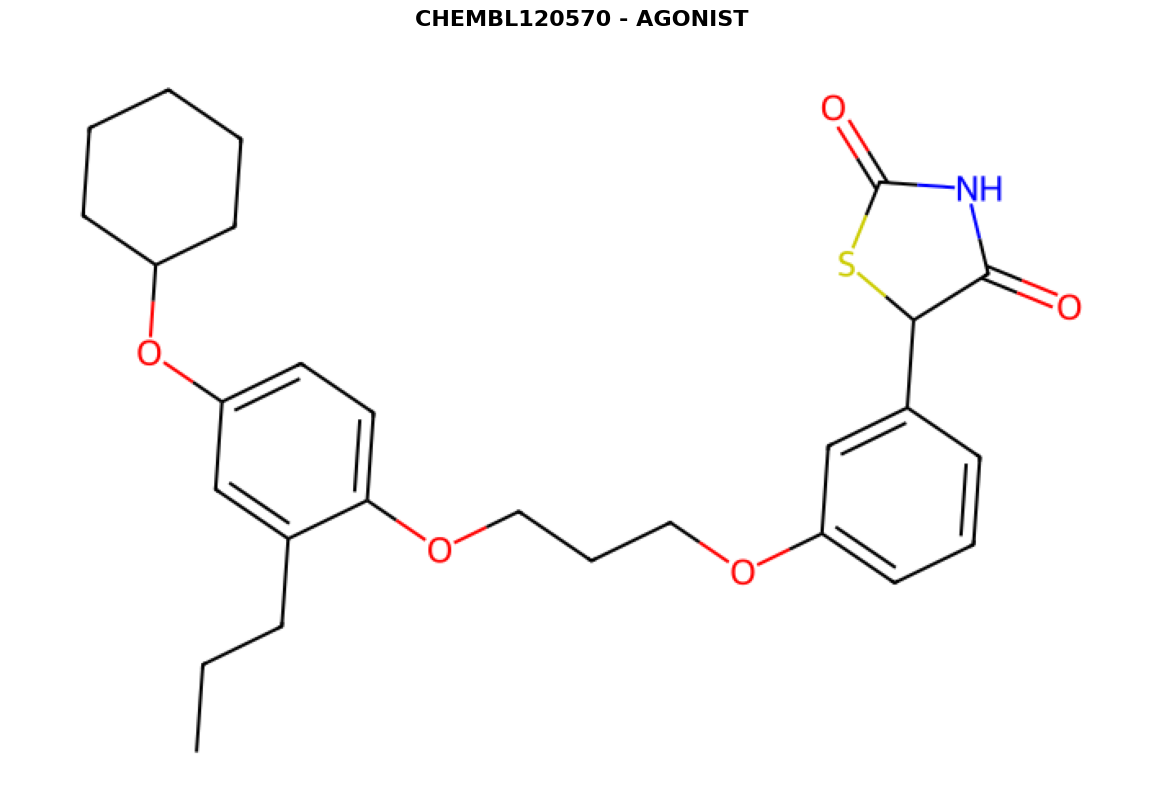

In [56]:
mol = Chem.MolFromSmiles(lig['smiles'])

if mol:
    img = Draw.MolToImage(mol, size=(700, 450))

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)
    ax.axis('off')

    title = f"{lig['ligand_id']} - {lig['class_label'].upper()}"
    if lig['is_decoy']:
        title += " (Decoy)"

    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Could not parse SMILES string")

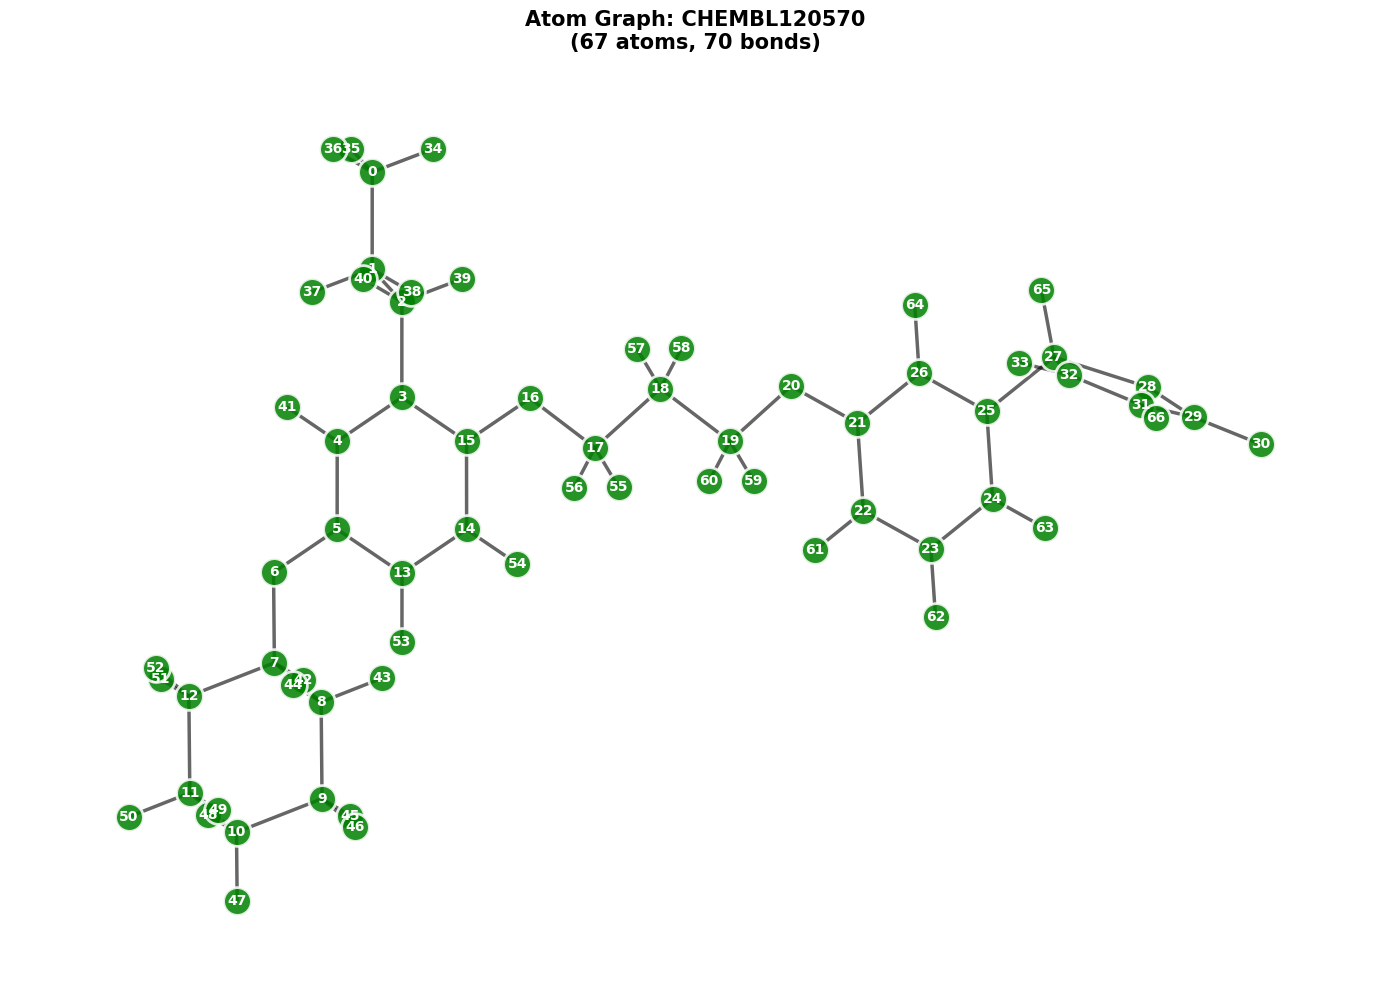

 Graph created: 67 nodes (atoms), 70 edges (bonds)


In [57]:
G = nx.Graph()

n_atoms = lig['x'].shape[0]
for i in range(n_atoms):
    G.add_node(i)

edge_index = lig['edge_index']
for i in range(edge_index.shape[1]):
    u, v = edge_index[0, i], edge_index[1, i]
    if u < v:
        G.add_edge(u, v)

if lig['pos'] is not None and lig['pos'].shape[0] == n_atoms:
    pos_3d = lig['pos']
    pos = {i: (pos_3d[i, 0], pos_3d[i, 1]) for i in range(n_atoms)}
else:
    pos = nx.spring_layout(G, seed=16)

fig, ax = plt.subplots(figsize=(14, 10))

nx.draw_networkx_nodes(G, pos,
                      node_color='green',
                      node_size=400,
                      alpha=0.85,
                      edgecolors='white',
                      linewidths=2,
                      ax=ax)

nx.draw_networkx_labels(G, pos,
                       font_size=10,
                       font_weight='bold',
                       font_color='white',
                       ax=ax)

nx.draw_networkx_edges(G, pos,
                      edge_color='black',
                      width=2.5,
                      alpha=0.6,
                      ax=ax)

ax.set_title(f"Atom Graph: {lig['ligand_id']}\n({n_atoms} atoms, {G.number_of_edges()} bonds)",
            fontsize=15, fontweight='bold', pad=15)

ax.axis('off')
plt.tight_layout()
plt.show()

print(f" Graph created: {n_atoms} nodes (atoms), {G.number_of_edges()} edges (bonds)")

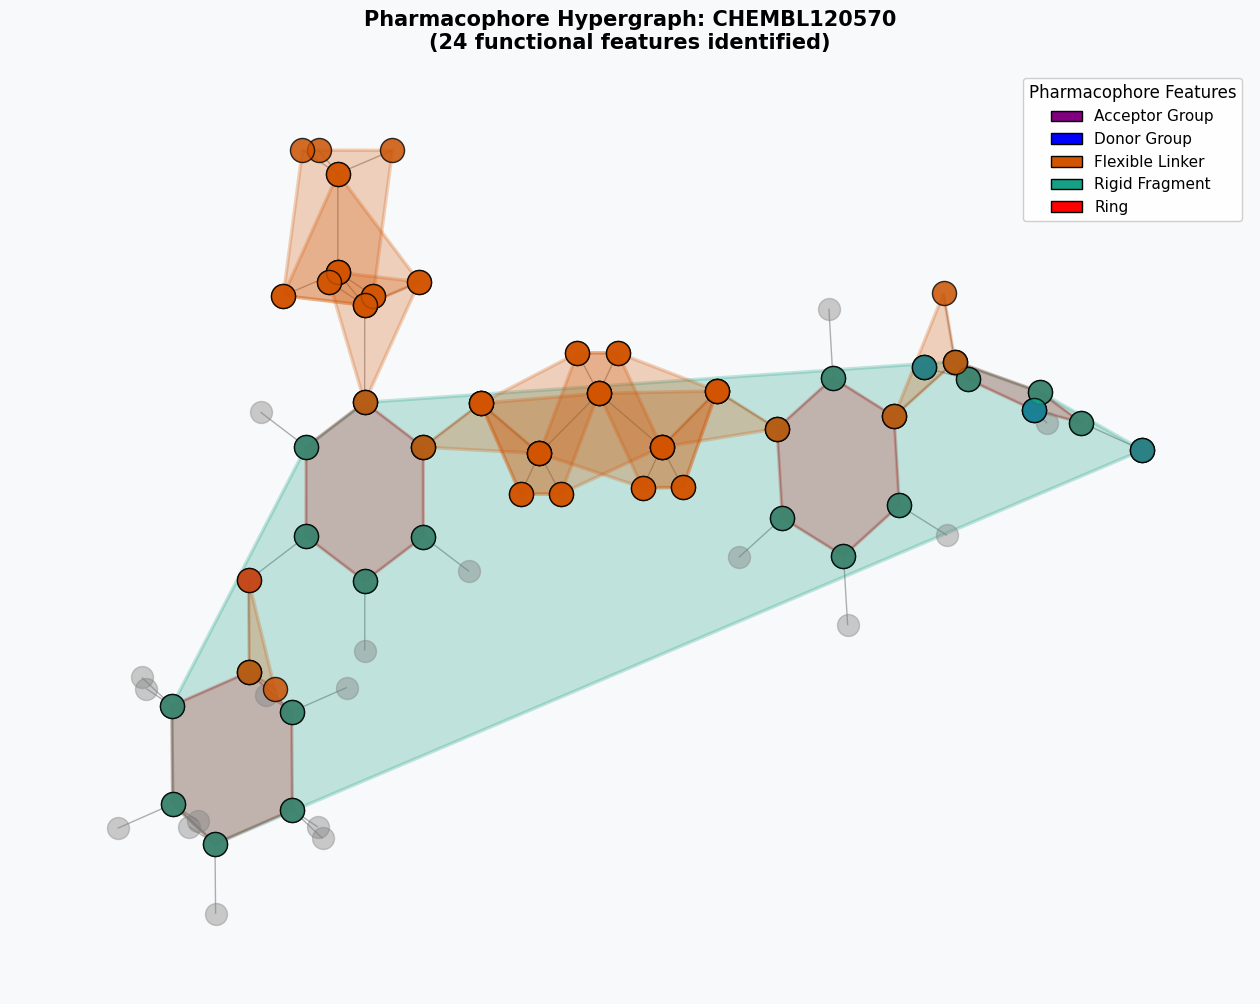

Pharmacophore Features Found:
  Ring: 4
  Donor Group: 1
  Acceptor Group: 7
  Rigid Fragment: 1
  Flexible Linker: 11


In [58]:
if lig['hyperedge_members'] and len(lig['hyperedge_members']) > 0:
    hyperedges = lig['hyperedge_members']
    hyperedge_attr = lig['hyperedge_attr']

    # Pharmacophore feature types
    type_names = [
        "ring", "donor_group", "acceptor_group",
        "cation_center", "anion_center", "halogen_donor",
        "aromatic_cluster", "rigid_fragment", "flexible_linker"
    ]

    # Decode hyperedge types from one-hot encoding
    hyperedge_types = []
    for i in range(len(hyperedges)):
        type_idx = np.argmax(hyperedge_attr[i, :9])
        hyperedge_types.append(type_names[type_idx])

    type_colors = {
        'ring': 'red',
        'donor_group': 'blue',
        'acceptor_group': 'purple',
        'cation_center': 'orange',
        'anion_center': '#1ABC9C',
        'halogen_donor': '#F39C12',
        'aromatic_cluster': '#8E44AD',
        'rigid_fragment': '#16A085',
        'flexible_linker': '#D35400',
    }


    fig, ax = plt.subplots(figsize=(16, 12))

    nx.draw_networkx_nodes(G, pos,
                          node_color='gray',
                          node_size=250,
                          alpha=0.4,
                          ax=ax)
    nx.draw_networkx_edges(G, pos,
                          edge_color='black',
                          width=1,
                          alpha=0.3,
                          ax=ax)
    # Convex hull draw
    for i, (members, htype) in enumerate(zip(hyperedges, hyperedge_types)):
        member_pos = np.array([pos[m] for m in members])

        if len(members) >= 3:
            from scipy.spatial import ConvexHull
            try:
                hull = ConvexHull(member_pos)
                hull_points = member_pos[hull.vertices]
                hull_points = np.vstack([hull_points, hull_points[0]])  # Close polygon

                ax.fill(hull_points[:, 0], hull_points[:, 1],
                       color=type_colors.get(htype, 'gray'),
                       alpha=0.25,
                       linewidth=2.5,
                       edgecolor=type_colors.get(htype, 'gray'))
            except Exception:
                pass

        nx.draw_networkx_nodes(G, pos,
                              nodelist=members,
                              node_color=type_colors.get(htype, 'gray'),
                              node_size=300,
                              alpha=0.8,
                              edgecolors='black',
                              linewidths=1,
                              ax=ax)

    unique_types = sorted(set(hyperedge_types))
    legend_elements = [
        Patch(facecolor=type_colors.get(t, 'gray'),
              edgecolor='black',
              linewidth=1,
              label=t.replace('_', ' ').title())
        for t in unique_types
    ]
    ax.legend(handles=legend_elements,
             loc='upper right',
             fontsize=11,
             framealpha=0.95,
             title='Pharmacophore Features',
             title_fontsize=12)

    ax.set_title(f"Pharmacophore Hypergraph: {lig['ligand_id']}\n({len(hyperedges)} functional features identified)",
                fontsize=15, fontweight='bold', pad=15)
    ax.axis('off')
    fig.patch.set_facecolor('#f8f9fa')

    plt.show()

    print("Pharmacophore Features Found:")
    for htype in type_names:
        count = hyperedge_types.count(htype)
        if count > 0:
            print(f"  {htype.replace('_', ' ').title()}: {count}")

## Section 3: Viz Protein Pocket Graph

Selecting one pocket to visualize:

- **Nodes** = Amino acid residues
- **Edges** = Spatial proximity


**Legend for Residue Types:**
- **Hydrophobic**
- **Polar**
- **Positive**
- **Negative**
- **Special**


In [63]:
# Select pocket by index (change this number to view different pockets)
pocket_idx = 69

In [64]:
# Validate index and get pocket
if pocket_idx >= len(pocket_graphs):
    print(f"Index {pocket_idx} out of range. Using index 0.")
    pocket_idx = 0

poc = pocket_graphs[pocket_idx]

print(f"SELECTED POCKET: {poc['target_id']} (Index: {pocket_idx}/{len(pocket_graphs)-1})")
print(f"- Conformation: {poc['state'].upper()}-bound")
print(f"- Residues: {poc['n_residues']}")
print(f"- Spatial connections: {poc['edge_index'].shape[1]}")
print(f"- State ID: {poc['state_id']}")

SELECTED POCKET: 3HO0 (Index: 69/159)
- Conformation: AGONIST-bound
- Residues: 36
- Spatial connections: 356
- State ID: 0


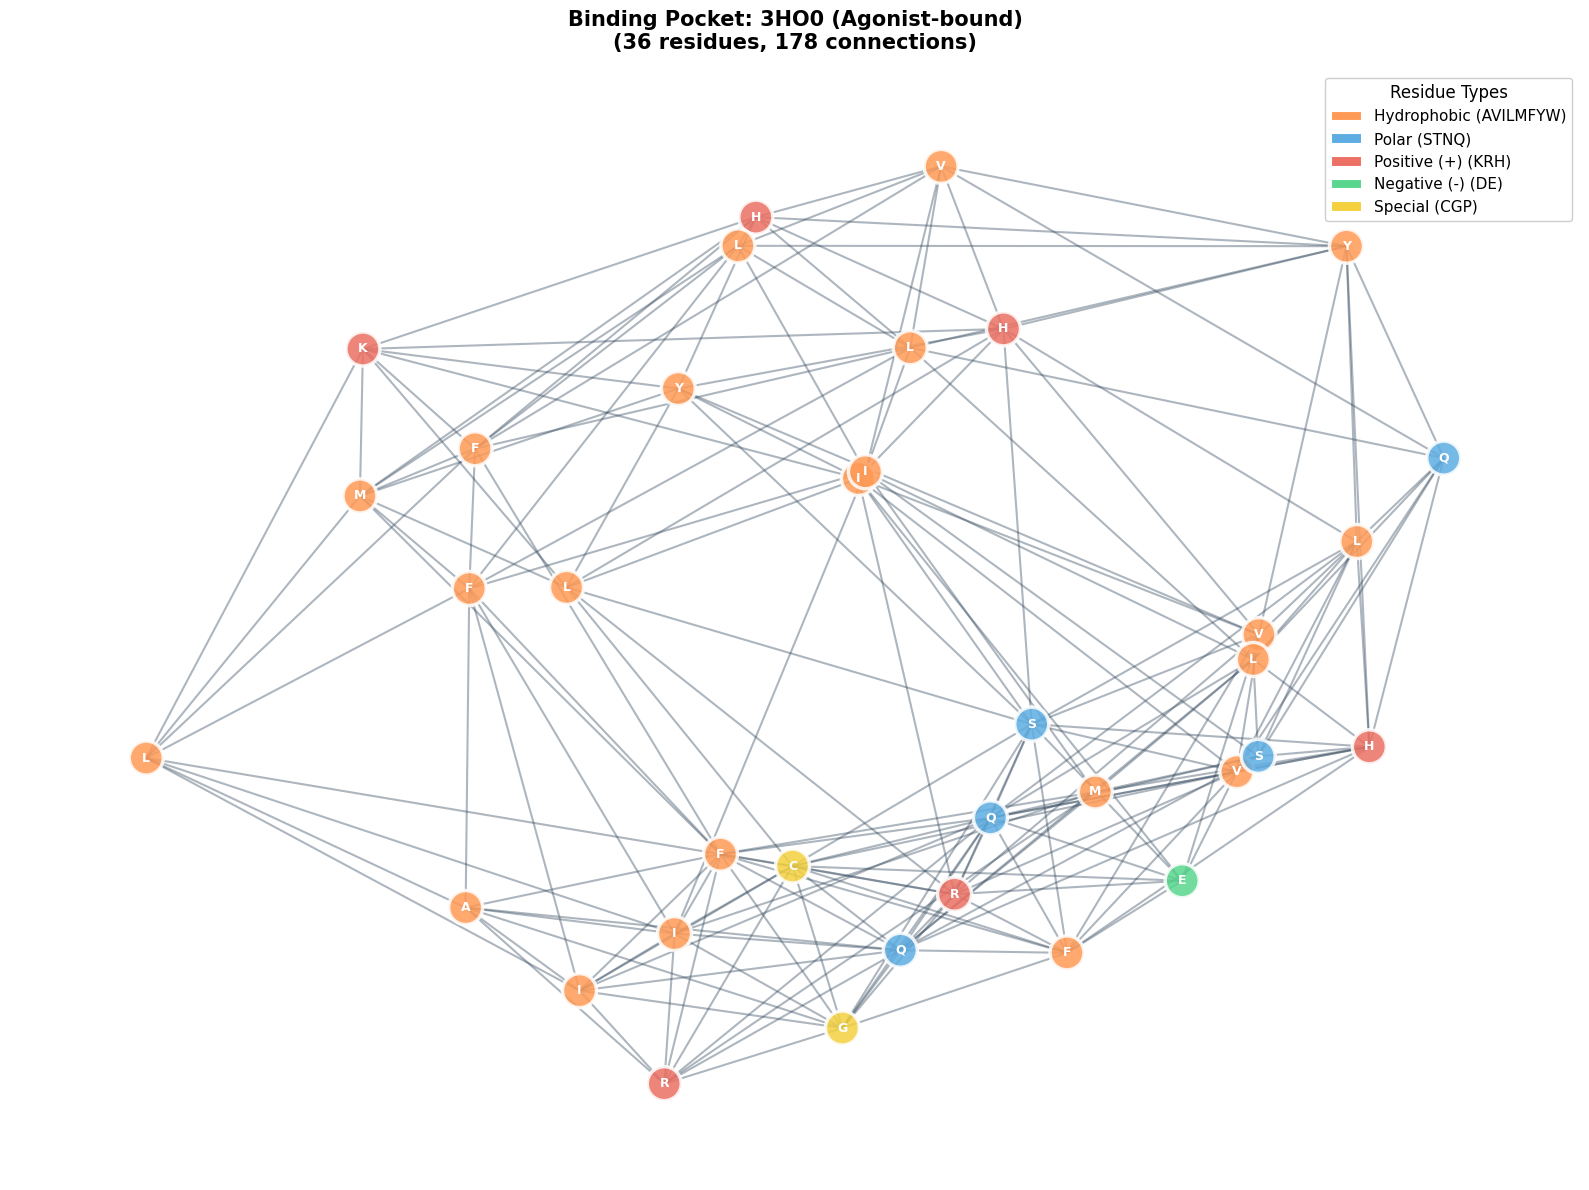

Pocket graph: 36 nodes (residues), 178 edges (spatial connections)


In [65]:
G_poc = nx.Graph()

n_res = poc['x'].shape[0]
for i in range(n_res):
    G_poc.add_node(i)

edge_index_poc = poc['edge_index']
for i in range(edge_index_poc.shape[1]):
    u, v = edge_index_poc[0, i], edge_index_poc[1, i]
    if u < v:
        G_poc.add_edge(u, v)

# Use C-alpha coordinates for layout
if poc['pos'] is not None and poc['pos'].shape[0] == n_res:
    pos_3d_poc = poc['pos']
    pos_poc = {i: (pos_3d_poc[i, 0], pos_3d_poc[i, 1]) for i in range(n_res)}
else:
    pos_poc = nx.spring_layout(G_poc, seed=16)

aa_order = "ACDEFGHIKLMNPQRSTVWY"
residue_types = []
for i in range(n_res):
    aa_idx = np.argmax(poc['x'][i, :20])
    residue_types.append(aa_order[aa_idx])

# Group residues by chemical properties
aa_groups = {
    'hydrophobic': 'AVILMFYW',
    'polar': 'STNQ',
    'charged_pos': 'KRH',
    'charged_neg': 'DE',
    'special': 'CGP',
}

group_colors = {
    'hydrophobic': '#FF9A56',
    'polar': '#5DADE2',
    'charged_pos': '#EC7063',
    'charged_neg': '#58D68D',
    'special': '#F4D03F',
}

node_colors = []
for aa in residue_types:
    for group, aas in aa_groups.items():
        if aa in aas:
            node_colors.append(group_colors[group])
            break
    else:
        node_colors.append('#95A5A6')  # Gray fallback


fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_nodes(G_poc, pos_poc,
                      node_color=node_colors,
                      node_size=600,
                      alpha=0.85,
                      edgecolors='white',
                      linewidths=2.5,
                      ax=ax)

nx.draw_networkx_edges(G_poc, pos_poc,
                      edge_color='#34495E',
                      width=1.5,
                      alpha=0.4,
                      ax=ax)

labels = {i: residue_types[i] for i in range(n_res)}
nx.draw_networkx_labels(G_poc, pos_poc, labels,
                       font_size=9,
                       font_weight='bold',
                       font_color='white',
                       ax=ax)

legend_elements = [
    Patch(facecolor=group_colors['hydrophobic'],
          edgecolor='white', linewidth=1.5,
          label='Hydrophobic (AVILMFYW)'),
    Patch(facecolor=group_colors['polar'],
          edgecolor='white', linewidth=1.5,
          label='Polar (STNQ)'),
    Patch(facecolor=group_colors['charged_pos'],
          edgecolor='white', linewidth=1.5,
          label='Positive (+) (KRH)'),
    Patch(facecolor=group_colors['charged_neg'],
          edgecolor='white', linewidth=1.5,
          label='Negative (-) (DE)'),
    Patch(facecolor=group_colors['special'],
          edgecolor='white', linewidth=1.5,
          label='Special (CGP)'),
]
ax.legend(handles=legend_elements,
         loc='upper right',
         fontsize=11,
         framealpha=0.95,
         title='Residue Types',
         title_fontsize=12)

state_title = poc['state'].capitalize()
ax.set_title(f"Binding Pocket: {poc['target_id']} ({state_title}-bound)\n({n_res} residues, {G_poc.number_of_edges()} connections)",
            fontsize=15, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Pocket graph: {n_res} nodes (residues), {G_poc.number_of_edges()} edges (spatial connections)")

## Section 4: Dataset Statistics

- **Size distributions**
- **Feature richness**
- **Data quality**

#### **Ligand Graph**

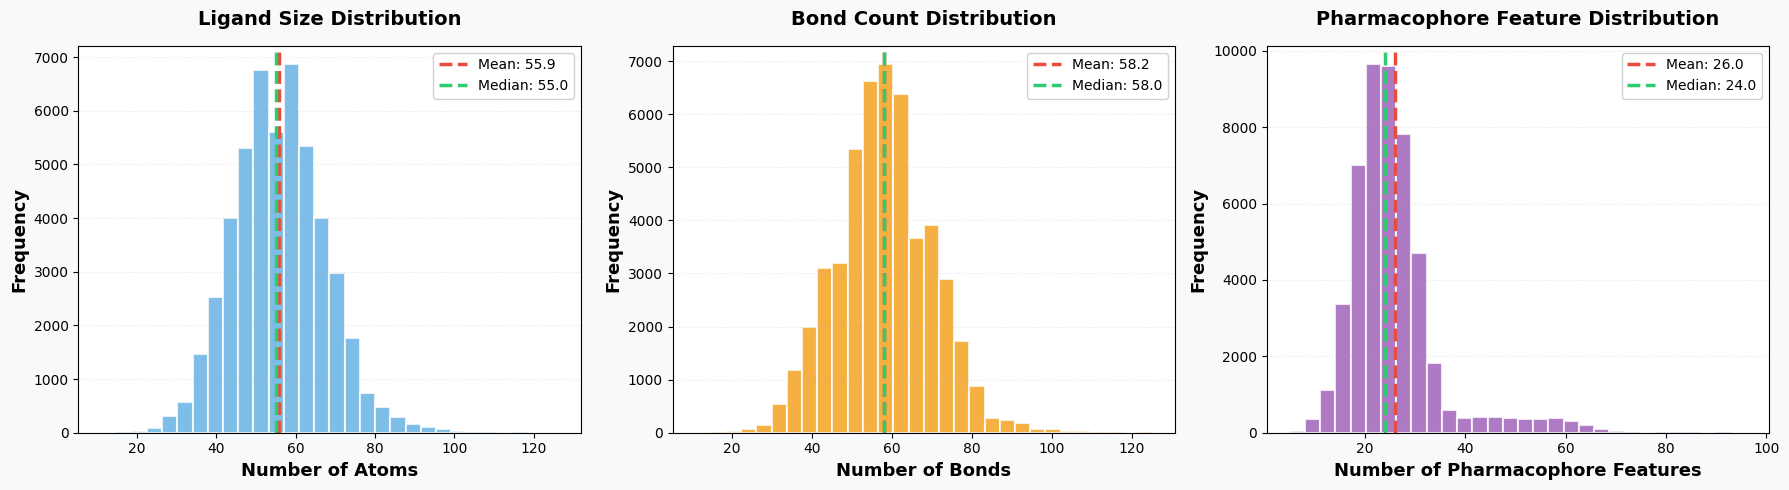

LIGAND STATISTICS SUMMARY
Atoms per molecule:
- Mean: 55.9 | Median: 55.0 | Std: 11.6
- Range: [11 - 126]

Bonds per molecule:
- Mean: 58.2 | Median: 58.0 | Std: 12.0
- Range: [11 - 125]

Pharmacophore features per molecule:
- Mean: 26.0 | Median: 24.0 | Std: 9.1
- Range: [5 - 96]


In [66]:
if ligand_graphs:
    # Collect key metrics
    n_atoms_list = [lg['x'].shape[0] for lg in ligand_graphs]
    n_bonds_list = [lg['edge_index'].shape[1] // 2 for lg in ligand_graphs]  # Undirected
    n_hyperedges_list = [len(lg['hyperedge_members']) if lg['hyperedge_members'] else 0
                        for lg in ligand_graphs]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor('#f8f9fa')

    # Atom Distribution
    axes[0].hist(n_atoms_list, bins=30, color='#5DADE2', edgecolor='white',
                alpha=0.8, linewidth=1.5)
    axes[0].set_xlabel('Number of Atoms', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Frequency', fontsize=13, fontweight='bold')
    axes[0].set_title('Ligand Size Distribution',
                     fontsize=14, fontweight='bold', pad=15)
    axes[0].axvline(np.mean(n_atoms_list), color='#E74C3C', linestyle='--',
                   linewidth=2.5, label=f'Mean: {np.mean(n_atoms_list):.1f}')
    axes[0].axvline(np.median(n_atoms_list), color='#2ECC71', linestyle='--',
                   linewidth=2.5, label=f'Median: {np.median(n_atoms_list):.1f}')
    axes[0].legend(framealpha=0.9, fontsize=10)
    axes[0].grid(axis='y', alpha=0.3, linestyle=':')

    # Bonds Distribution
    axes[1].hist(n_bonds_list, bins=30, color='#F39C12', edgecolor='white',
                alpha=0.8, linewidth=1.5)
    axes[1].set_xlabel('Number of Bonds', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Frequency', fontsize=13, fontweight='bold')
    axes[1].set_title('Bond Count Distribution',
                     fontsize=14, fontweight='bold', pad=15)
    axes[1].axvline(np.mean(n_bonds_list), color='#E74C3C', linestyle='--',
                   linewidth=2.5, label=f'Mean: {np.mean(n_bonds_list):.1f}')
    axes[1].axvline(np.median(n_bonds_list), color='#2ECC71', linestyle='--',
                   linewidth=2.5, label=f'Median: {np.median(n_bonds_list):.1f}')
    axes[1].legend(framealpha=0.9, fontsize=10)
    axes[1].grid(axis='y', alpha=0.3, linestyle=':')

    # Hyperedges Distribution
    axes[2].hist(n_hyperedges_list, bins=30, color='#9B59B6', edgecolor='white',
                alpha=0.8, linewidth=1.5)
    axes[2].set_xlabel('Number of Pharmacophore Features', fontsize=13, fontweight='bold')
    axes[2].set_ylabel('Frequency', fontsize=13, fontweight='bold')
    axes[2].set_title('Pharmacophore Feature Distribution',
                     fontsize=14, fontweight='bold', pad=15)
    axes[2].axvline(np.mean(n_hyperedges_list), color='#E74C3C', linestyle='--',
                   linewidth=2.5, label=f'Mean: {np.mean(n_hyperedges_list):.1f}')
    axes[2].axvline(np.median(n_hyperedges_list), color='#2ECC71', linestyle='--',
                   linewidth=2.5, label=f'Median: {np.median(n_hyperedges_list):.1f}')
    axes[2].legend(framealpha=0.9, fontsize=10)
    axes[2].grid(axis='y', alpha=0.3, linestyle=':')

    plt.tight_layout()
    plt.show()

    print("LIGAND STATISTICS SUMMARY")
    print("Atoms per molecule:")
    print(f"- Mean: {np.mean(n_atoms_list):.1f} | Median: {np.median(n_atoms_list):.1f} | Std: {np.std(n_atoms_list):.1f}")
    print(f"- Range: [{min(n_atoms_list)} - {max(n_atoms_list)}]")
    print("\nBonds per molecule:")
    print(f"- Mean: {np.mean(n_bonds_list):.1f} | Median: {np.median(n_bonds_list):.1f} | Std: {np.std(n_bonds_list):.1f}")
    print(f"- Range: [{min(n_bonds_list)} - {max(n_bonds_list)}]")
    print("\nPharmacophore features per molecule:")
    print(f"- Mean: {np.mean(n_hyperedges_list):.1f} | Median: {np.median(n_hyperedges_list):.1f} | Std: {np.std(n_hyperedges_list):.1f}")
    print(f"- Range: [{min(n_hyperedges_list)} - {max(n_hyperedges_list)}]")



#### **Pocket Graph**

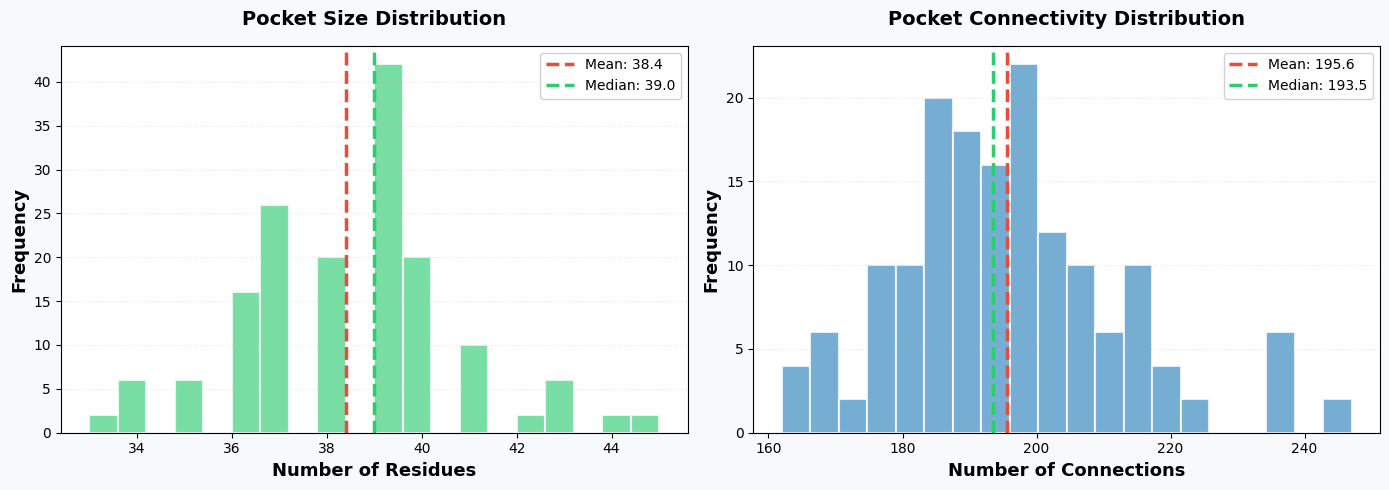

POCKET STATISTICS SUMMARY
Residues per pocket:
- Mean: 38.4 | Median: 39.0 | Std: 2.3
- Range: [33 - 45]

Spatial connections per pocket:
- Mean: 195.6 | Median: 193.5 | Std: 16.6
- Range: [162 - 247]
- Average pocket contains ~39 residues
- Average connectivity: 10.2 neighbors per residue


In [67]:
if pocket_graphs:

    n_res_list = [pg['n_residues'] for pg in pocket_graphs]
    n_edges_list = [pg['edge_index'].shape[1] // 2 for pg in pocket_graphs]  # Undirected

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#f8f9fa')

    # Residue Count Distribution
    axes[0].hist(n_res_list, bins=20, color='#58D68D', edgecolor='white',
                alpha=0.8, linewidth=1.5)
    axes[0].set_xlabel('Number of Residues', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Frequency', fontsize=13, fontweight='bold')
    axes[0].set_title('Pocket Size Distribution',
                     fontsize=14, fontweight='bold', pad=15)
    axes[0].axvline(np.mean(n_res_list), color='#E74C3C', linestyle='--',
                   linewidth=2.5, label=f'Mean: {np.mean(n_res_list):.1f}')
    axes[0].axvline(np.median(n_res_list), color='#2ECC71', linestyle='--',
                   linewidth=2.5, label=f'Median: {np.median(n_res_list):.1f}')
    axes[0].legend(framealpha=0.9, fontsize=10)
    axes[0].grid(axis='y', alpha=0.3, linestyle=':')

    # Edge Count Distribution
    axes[1].hist(n_edges_list, bins=20, color='#5499C7', edgecolor='white',
                alpha=0.8, linewidth=1.5)
    axes[1].set_xlabel('Number of Connections', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Frequency', fontsize=13, fontweight='bold')
    axes[1].set_title('Pocket Connectivity Distribution',
                     fontsize=14, fontweight='bold', pad=15)
    axes[1].axvline(np.mean(n_edges_list), color='#E74C3C', linestyle='--',
                   linewidth=2.5, label=f'Mean: {np.mean(n_edges_list):.1f}')
    axes[1].axvline(np.median(n_edges_list), color='#2ECC71', linestyle='--',
                   linewidth=2.5, label=f'Median: {np.median(n_edges_list):.1f}')
    axes[1].legend(framealpha=0.9, fontsize=10)
    axes[1].grid(axis='y', alpha=0.3, linestyle=':')

    plt.tight_layout()
    plt.show()

    print("POCKET STATISTICS SUMMARY")
    print("Residues per pocket:")
    print(f"- Mean: {np.mean(n_res_list):.1f} | Median: {np.median(n_res_list):.1f} | Std: {np.std(n_res_list):.1f}")
    print(f"- Range: [{min(n_res_list)} - {max(n_res_list)}]")
    print("\nSpatial connections per pocket:")
    print(f"- Mean: {np.mean(n_edges_list):.1f} | Median: {np.median(n_edges_list):.1f} | Std: {np.std(n_edges_list):.1f}")
    print(f"- Range: [{min(n_edges_list)} - {max(n_edges_list)}]")
    avg_degree = 2 * np.mean(n_edges_list) / np.mean(n_res_list)
    print(f"- Average pocket contains ~{np.median(n_res_list):.0f} residues")
    print(f"- Average connectivity: {avg_degree:.1f} neighbors per residue")


## Section 5: Pharmacophore Feature Analysis

- **Rings** - π-π stacking with aromatic residues
- **H-bond donors**
- **H-bond acceptors**
- **Charged centers** - Electrostatic interactions etc.


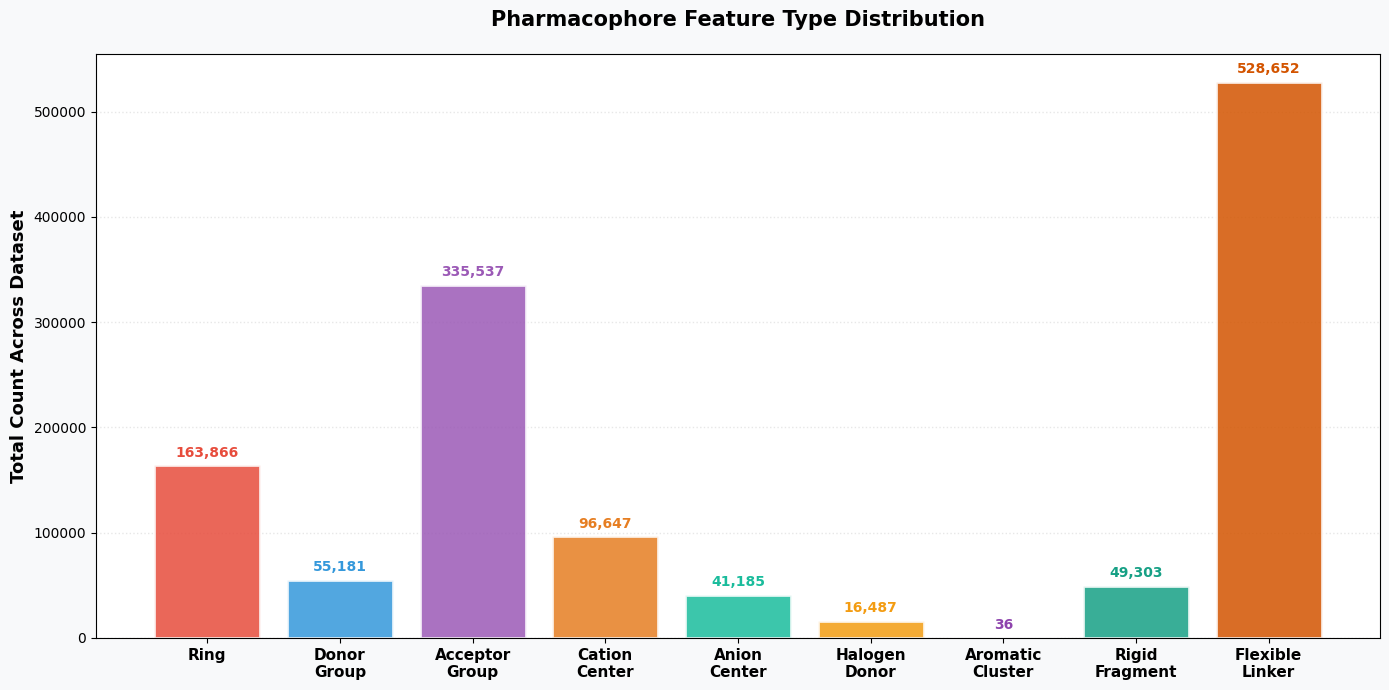


PHARMACOPHORE FEATURE BREAKDOWN
1. Flexible Linker           528652 ( 41.1%) ||||||||||||||||||||
2. Acceptor Group            335537 ( 26.1%) |||||||||||||
3. Ring                      163866 ( 12.7%) ||||||
4. Cation Center              96647 (  7.5%) |||
5. Donor Group                55181 (  4.3%) ||
6. Rigid Fragment             49303 (  3.8%) |
7. Anion Center               41185 (  3.2%) |
8. Halogen Donor              16487 (  1.3%) 
9. Aromatic Cluster              36 (  0.0%) 

- TOTAL FEATURES: 1,286,894
- ACROSS 49,573 LIGANDS
- AVG PER LIGAND: 26.0


In [68]:
if ligand_graphs:
    type_names = [
        "ring", "donor_group", "acceptor_group",
        "cation_center", "anion_center", "halogen_donor",
        "aromatic_cluster", "rigid_fragment", "flexible_linker"
    ]

    # Count each feature type across all ligands
    type_counts = {t: 0 for t in type_names}
    for lg in ligand_graphs:
        if lg['hyperedge_members'] and lg['hyperedge_attr'] is not None:
            for i in range(len(lg['hyperedge_members'])):
                type_idx = np.argmax(lg['hyperedge_attr'][i, :9])
                type_counts[type_names[type_idx]] += 1

    # Create beautiful bar chart
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('#f8f9fa')

    types = list(type_counts.keys())
    counts = list(type_counts.values())

    # Gradient color scheme
    colors = ['#E74C3C', '#3498DB', '#9B59B6', '#E67E22', '#1ABC9C',
              '#F39C12', '#8E44AD', '#16A085', '#D35400']

    bars = ax.bar(range(len(types)), counts,
                  color=colors,
                  edgecolor='white',
                  alpha=0.85,
                  linewidth=2)

    ax.set_xticks(range(len(types)))
    ax.set_xticklabels([t.replace('_', '\n').title() for t in types],
                       rotation=0, ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('Total Count Across Dataset', fontsize=13, fontweight='bold')
    ax.set_title('Pharmacophore Feature Type Distribution',
                fontsize=15, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1)
    ax.set_axisbelow(True)

    for i, (bar, count) in enumerate(zip(bars, counts)):
        if count > 0:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + max(counts)*0.01,
                   f'{count:,}',
                   ha='center', va='bottom',
                   fontsize=10, fontweight='bold',
                   color=colors[i])

    plt.tight_layout()
    plt.show()

    total_features = sum(type_counts.values())
    print("\nPHARMACOPHORE FEATURE BREAKDOWN")

    # Sort by frequency
    sorted_types = sorted(type_counts.items(), key=lambda x: x[1], reverse=True)

    for rank, (feat_type, count) in enumerate(sorted_types, 1):
        if count > 0:
            percentage = (count / total_features) * 100
            bar = '|' * int(percentage / 2)  # Visual bar
            print(f"{rank}. {feat_type.replace('_', ' ').title():<25} {count:>6} ({percentage:>5.1f}%) {bar}")

    print(f"\n- TOTAL FEATURES: {total_features:,}")
    print(f"- ACROSS {len(ligand_graphs):,} LIGANDS")
    print(f"- AVG PER LIGAND: {total_features/len(ligand_graphs):.1f}")


---